In [1]:
# pip install kagglehub[pandas-datasets]

import kagglehub

# Download dataset files locally
path = kagglehub.dataset_download(
    "corrieaar/apartment-rental-offers-in-germany"
)

print(path)

Download already complete (97545791 bytes).
Extracting files...
/Users/harshkataria/.cache/kagglehub/datasets/corrieaar/apartment-rental-offers-in-germany/versions/6


In [2]:
import os

print(os.listdir(path))

['immo_data.csv']


In [3]:
# Run this entire block

# pip install -U kagglehub pandas

import shutil
import os
import kagglehub
import pandas as pd

# Clear corrupted KaggleHub cache
cache_dir = os.path.expanduser("~/.cache/kagglehub")

if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

print("Cache cleared.")

# Download dataset manually
path = kagglehub.dataset_download(
    "corrieaar/apartment-rental-offers-in-germany"
)

print("Dataset downloaded to:", path)

# Check files inside dataset
files = os.listdir(path)
print("Files:", files)

# Load CSV file
csv_file = [f for f in files if f.endswith(".csv")][0]

df = pd.read_csv(os.path.join(path, csv_file))

# Show dataset
print(df.head())
print("\nShape:", df.shape)

Cache cleared.


100%|██████████| 93.0M/93.0M [00:03<00:00, 31.6MB/s]

Extracting files...


Dataset downloaded to: /Users/harshkataria/.cache/kagglehub/datasets/corrieaar/apartment-rental-offers-in-germany/versions/6
Files: ['immo_data.csv']
                regio1  serviceCharge                     heatingType  \
0  Nordrhein_Westfalen         245.00                 central_heating   
1      Rheinland_Pfalz         134.00  self_contained_central_heating   
2              Sachsen         255.00                   floor_heating   
3              Sachsen          58.15                district_heating   
4               Bremen         138.00  self_contained_central_heating   

  telekomTvOffer  telekomHybridUploadSpeed  newlyConst  balcony  picturecount  \
0  ONE_YEAR_FREE                       NaN       False    False             6   
1  ONE_YEAR_FREE                       NaN       False     True             8   
2  ONE_YEAR_FREE                      10.0        True     True             8   
3  ONE_YEAR_FREE                       NaN       False     True             9   
4     

In [4]:
import matplotlib.pyplot as plt
# print(df.info())
print(df.describe())


       serviceCharge  telekomHybridUploadSpeed   picturecount     pricetrend  \
count  261941.000000                   45020.0  268850.000000  267018.000000   
mean      151.206113                      10.0       9.791958       3.389001   
std       308.295790                       0.0       6.408399       1.964874   
min         0.000000                      10.0       0.000000     -12.330000   
25%        95.000000                      10.0       6.000000       2.000000   
50%       135.000000                      10.0       9.000000       3.390000   
75%       190.000000                      10.0      13.000000       4.570000   
max    146118.000000                      10.0     121.000000      14.920000   

       telekomUploadSpeed     totalRent  yearConstructed       scoutId  \
count       235492.000000  2.283330e+05    211805.000000  2.688500e+05   
mean            28.804928  9.013315e+02      1966.400590  1.069697e+08   
std             16.337151  3.323833e+04        46.992207 

In [5]:
print(df['totalRent'].describe())
print(df['totalRent'].value_counts().head(10))
# 

count    2.283330e+05
mean     9.013315e+02
std      3.323833e+04
min      0.000000e+00
25%      4.698000e+02
50%      6.500000e+02
75%      9.850000e+02
max      1.575154e+07
Name: totalRent, dtype: float64
totalRent
500.0    1897
450.0    1892
600.0    1805
550.0    1668
400.0    1500
750.0    1495
650.0    1486
800.0    1427
700.0    1417
900.0    1399
Name: count, dtype: int64


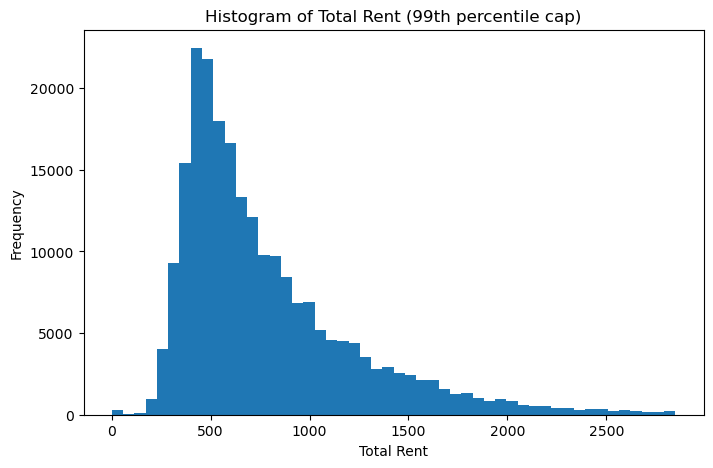

In [6]:
plt.figure(figsize=(8,5))
plt.hist(df['totalRent'].dropna(), bins=50, range=(0, df['totalRent'].quantile(0.99)))
plt.xlabel('Total Rent')
plt.ylabel('Frequency')
plt.title('Histogram of Total Rent (99th percentile cap)')
plt.show()

In [7]:
df.columns

Index(['regio1', 'serviceCharge', 'heatingType', 'telekomTvOffer',
       'telekomHybridUploadSpeed', 'newlyConst', 'balcony', 'picturecount',
       'pricetrend', 'telekomUploadSpeed', 'totalRent', 'yearConstructed',
       'scoutId', 'noParkSpaces', 'firingTypes', 'hasKitchen', 'geo_bln',
       'cellar', 'yearConstructedRange', 'baseRent', 'houseNumber',
       'livingSpace', 'geo_krs', 'condition', 'interiorQual', 'petsAllowed',
       'street', 'streetPlain', 'lift', 'baseRentRange', 'typeOfFlat',
       'geo_plz', 'noRooms', 'thermalChar', 'floor', 'numberOfFloors',
       'noRoomsRange', 'garden', 'livingSpaceRange', 'regio2', 'regio3',
       'description', 'facilities', 'heatingCosts', 'energyEfficiencyClass',
       'lastRefurbish', 'electricityBasePrice', 'electricityKwhPrice', 'date'],
      dtype='object')

In [9]:
import numpy as np

# remove nulls and outliers
remove_outliers = df[
    df['totalRent'].notna() &
    (df['totalRent'] <= 5000) &
    (df['totalRent'] >= 0)
].copy()

# log transform target
remove_outliers['totalRent_log'] = np.log1p(remove_outliers['totalRent'])

# reducing the dataset size for faster processing (optional)
df_subset = remove_outliers.head(1000).copy()
# Features table 
X = df_subset.drop(columns=['totalRent', 'totalRent_log'])

# Target
y = df_subset['totalRent_log']

result_table = df_subset[['totalRent', 'totalRent_log']]
# print(result_table.head())
# print(y.head())

numeric_cols     = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

# print("Numeric columns:", X[numeric_cols[0]])
# print("Categorical columns:", categorical_cols)

    


In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train

,regio1,serviceCharge,heatingType,telekomTvOffer,telekomHybridUploadSpeed,newlyConst,balcony,picturecount,pricetrend,telekomUploadSpeed,...,regio2,regio3,description,facilities,heatingCosts,energyEfficiencyClass,lastRefurbish,electricityBasePrice,electricityKwhPrice,date
34,Hessen,260.00,wood_pellet_heating,ONE_YEAR_FREE,NaN,False,False,15,5.22,40.0,...,Groß_Gerau_Kreis,Raunheim,"Wir bieten folgende neue, moderne und möbliert...","Details im Überblick:\n- separate Wohn-, Schla...",NaN,NaN,NaN,NaN,NaN,Oct19
647,Sachsen_Anhalt,137.48,central_heating,ONE_YEAR_FREE,NaN,False,False,8,3.23,10.0,...,Magdeburg,Stadtfeld_Ost,Der mitte der 90er Jahre errichtete Altbau ist...,- Laminat\n- Badezimmer mit Wanne\n- Hausmeist...,NaN,NaN,2007.0,90.76,0.1985,Sep18
835,Brandenburg,112.51,district_heating,ONE_YEAR_FREE,NaN,False,False,3,-0.95,40.0,...,Cottbus,Sachsendorf,NaN,Ausstattungsmerkmale:\r- teilmodernisiert vor ...,NaN,NaN,NaN,NaN,NaN,Oct19
672,Thüringen,140.00,central_heating,ONE_YEAR_FREE,NaN,False,True,10,2.78,40.0,...,Gera,Lusan_Laune,Es handelt sich um eine Wohnung in einem 5-ges...,- Einzugsbereit für Sie\r\n- Bodenbelag PVC in...,NaN,NaN,1997.0,NaN,NaN,Oct19
994,Brandenburg,237.69,district_heating,ONE_YEAR_FREE,NaN,False,False,4,4.23,40.0,...,Potsdam,Südliche_Innenstadt,Es handelt sich um ein 15-geschossiges Hochhau...,- gefliestes Wannenbad\r- offene Küche mit Fli...,70.67,NaN,NaN,NaN,NaN,May19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,Niedersachsen,125.00,gas_heating,ONE_YEAR_FREE,10.0,False,True,9,4.07,10.0,...,Harburg_Kreis,Buchholz_in_der_Nordheide,\rEnergieausweis:\rGültig vom 27.04.2010 bis 2...,"3 ZW, Küche mit EBK, Flur, Wannenbad, Abstellk...",80.00,NaN,NaN,NaN,NaN,Feb20
330,Hessen,225.00,central_heating,ONE_YEAR_FREE,NaN,False,True,7,6.02,40.0,...,Bergstraße_Kreis,Bensheim,Das moderne Objekt wurde im Jahr 1991 erbaut. ...,Das Erdgeschoß ist (außer Küche/Bad/Gäste-Dusc...,NaN,NaN,2013.0,90.76,0.1915,Sep18
1020,Bayern,48.00,central_heating,ONE_YEAR_FREE,NaN,False,False,7,5.71,40.0,...,München,Haidhausen,*Wohnzimmer mit Einbauküche\n*Schlafzimmer\n*h...,"* EBK\n* Möblierung: Bett mit Lattenrost, Schr...",56.00,NaN,NaN,NaN,NaN,Oct19
536,Sachsen_Anhalt,55.00,gas_heating,ONE_YEAR_FREE,NaN,False,True,11,3.92,40.0,...,Altmarkkreis_Salzwedel,Gardelegen,Auf ca. 415 m² Wohnfläche befinden sich in die...,Die Wohnungen werden noch bis zum 1. Juli 2019...,35.00,A,2019.0,NaN,NaN,May19


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.linear_model import LinearRegression

# 1. Build sub-pipelines that fix missing values (NaNs) FIRST
numeric_transformer = Pipeline(steps=[
    ('imputation_mean', SimpleImputer(missing_values=np.nan, strategy='mean')),  # Replaces missing numbers with column average
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputation_constant', SimpleImputer(strategy='constant', fill_value='missing')),  # Replaces missing text
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 2. Re-combine them into your preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', numeric_transformer, numeric_cols),
        ('categorical', categorical_transformer, categorical_cols)
    ]
)

# 3. Re-build the main pipeline
model_pipeline = make_pipeline(
    preprocessor,
    LinearRegression()
)

# steps = [('scaler', StandardScaler()),
#          ('pca', PCA(n_components=3)),
#          ('svr', SVC())]
# 4. Train using the updated pipeline (This will now handle BOTH text and NaNs!)
model_pipeline.fit(X_train, y_train)

# 5. Predict using the pipeline
predictions = model_pipeline.predict(X_test)

print("Pipeline complete! First 5 predictions:", predictions[:5])

Pipeline complete! First 5 predictions: [5.78565536 5.90723762 6.75024207 6.37530686 5.88054613]


In [27]:
# Convert the log predictions back to Euros
real_euros = np.expm1(predictions[:5])

print("Predicted Rent in Euros:")
print(real_euros)

Predicted Rent in Euros:
[324.59535109 366.68905368 853.26552921 586.16558245 357.00470586]


In [ ]:
# # displaying pipeline with standard scaler, dimension reduction, and estimator

# pipeline2 = Pipeline(steps)
# pipeline2.fit(X_train, y_train)



ValueError: could not convert string to float: 'Hessen'